In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR


In [3]:
df = pd.read_csv(r'data\StudentsPerformance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
x = df.drop(['math score'], axis=1)
y = df['math score']

In [7]:
# create column transform with 3 types of transformers
num_features = x.select_dtypes(exclude=['object']).columns
cat_features = x.select_dtypes(include=['object']).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')


preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', categorical_transformer, cat_features),
        ('StandardScaler', numeric_transformer, num_features)
    ]
)

C:\Users\pawan\AppData\Local\Temp\ipykernel_11492\3337088781.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include=['object']).columns


In [8]:
x = preprocessor.fit_transform(x)

In [10]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape

(800, 19)

In [13]:
# create a eval function to give all the metrics in one go after model training
def eval_model(true, pred):
    mse = mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    return mse, r2, mae

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'XGB': XGBRegressor(),
    'CatBoost': CatBoostRegressor(verbose=0),
    'Ada': AdaBoostRegressor(),
    }


model_list = []
r2_list = []

for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mse, model_train_r2, model_train_mae = eval_model(y_train, y_train_pred)
    model_test_mse, model_test_r2, model_test_mae = eval_model(y_test, y_test_pred)

    print(f'{list(models.keys())[i]} Train MSE: {model_train_mse}, Train R2: {model_train_r2}, Train MAE: {model_train_mae}')
    print(f'{list(models.keys())[i]} Test MSE: {model_test_mse}, Test R2: {model_test_r2}, Test MAE: {model_test_mae}')
    print('=-=-='*10)
    print('\n')

    model_list.append(list(models.keys())[i])
    r2_list.append(model_test_r2)

Linear Regression Train MSE: 28.334870380648585, Train R2: 0.8743172040139593, Train MAE: 4.266711846071957
Linear Regression Test MSE: 29.095169866715487, Test R2: 0.8804332983749565, Test MAE: 4.21476314247485
=-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-=


Ridge Train MSE: 28.337788233082442, Train R2: 0.8743042615212909, Train MAE: 4.264987823725981
Ridge Test MSE: 29.056272192348295, Test R2: 0.8805931485028737, Test MAE: 4.211100688014261
=-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-=


Lasso Train MSE: 43.4784040058558, Train R2: 0.8071462015863456, Train MAE: 5.206302661246528
Lasso Test MSE: 42.50641683841164, Test R2: 0.8253197323627852, Test MAE: 5.157881810347764
=-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-=


KNN Train MSE: 32.57995, Train R2: 0.8554876322327585, Train MAE: 4.51675
KNN Test MSE: 52.6066, Test R2: 0.7838129945787431, Test MAE: 5.621
=-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-==-=-=


Decision Tree Train MSE: 0.078125, Train R2: 0.999653466971

In [17]:
pd.DataFrame({'Model': model_list, 'R2 Score': r2_list}).sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
1,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoost,0.851632
5,Random Forest,0.848232
8,Ada,0.844620
6,XGB,0.827797
2,Lasso,0.825320
3,KNN,0.783813
4,Decision Tree,0.748642


In [18]:
# choosing linear regression for hyperparameter tuning as it is the best performing model
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
score = r2_score(y_test, y_pred) * 100
print(f'R2 Score: {score}')

R2 Score: 88.04332983749565


Text(0.5, 1.0, 'Actual vs Predicted Values')

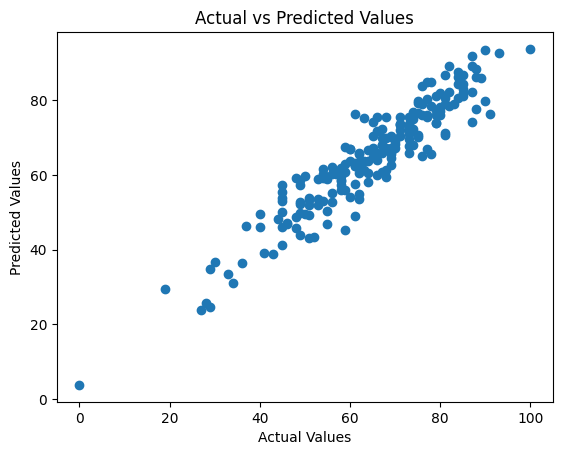

In [21]:
# plot y_pred and y_test
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')




<Axes: xlabel='math score'>

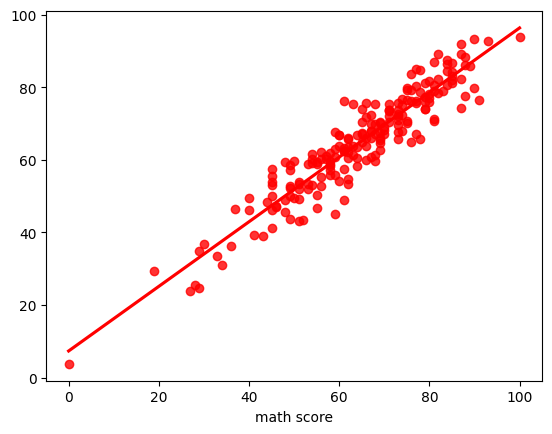

In [22]:
sns.regplot(x = y_test, y = y_pred, ci = None, color = 'red')